# Zero-Shot Fluorescence Microscopy Restoration (ZS-DeconvNet)

**Paper:** Qiao et al., *Nature Communications* 15, 4180 (2024) — "Zero-shot learning enables instant denoising and super-resolution in optical fluorescence microscopy"

This notebook demonstrates the full ZS-DeconvNet pipeline on TIRF fluorescence images of Microtubules.

**Key problem:** At low laser power, Microtubule images have only ~10 ADU signal above a ~100 ADU camera background — extremely low SNR.  Additionally, the PSF blurs filament structures whose true width (~25 nm) is far below the diffraction limit. We want to both denoise and deconvolve without any clean reference images.

**ZS-DeconvNet's solution:** Two U-Nets are trained jointly using zero-shot self-supervised learning.

**Stage 1 — Denoising via recorruption.** From each noisy image $y$, we generate a training pair:

$$\hat{y} = y + \alpha g, \qquad \bar{y} = y - \tfrac{1}{\alpha}g, \qquad g \sim \mathcal{N}(0,\,\sigma^2(y) \cdot I)$$

where $\sigma^2(y) = \beta_1 H(y-b) + \beta_2$. Minimising $\|f_\text{den}(\hat{y}) - \bar{y}\|^2$ is equivalent to supervised denoising.

**Stage 2 — Deconvolution via PSF consistency.** The Stage 2 network $f_\text{dec}$ is trained jointly with the constraint that its output, when re-blurred with the PSF, should match the observed image:

$$\mathcal{L}_\text{dec} = \|(f_\text{dec}(f_\text{den}(\hat{y})) * \text{PSF}) - \bar{y}\|^2 + \lambda\,\mathcal{R}_\text{Hessian}$$

The combined loss is $\mathcal{L} = 0.5\,\mathcal{L}_\text{den} + 0.5\,\mathcal{L}_\text{dec}$.

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd())

import numpy as np
import matplotlib.pyplot as plt
import json
import torch

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())

PyTorch: 2.9.1+cu128
CUDA available: True


## 1. Load data and precomputed outputs

We load the results from `evaluation/reference_outputs/` (generated by `main.py`) so this notebook runs in seconds.

In [ ]:
task_root = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()

# Load data
raw      = np.load(os.path.join(task_root, 'data', 'raw_data.npz'))
with open(os.path.join(task_root, 'data', 'meta_data.json')) as f:
    meta = json.load(f)

measurements = raw['measurements']        # (55, 502, 502) float32
psf          = raw['psf'][0]             # (32, 32)  normalised PSF kernel
noisy        = measurements[0]            # test frame (frame 01)

# Load precomputed outputs
ref_dir     = os.path.join(task_root, 'evaluation', 'reference_outputs')
denoised    = np.load(os.path.join(ref_dir, 'denoised.npy'))        # (502, 502) float32
deconvolved = np.load(os.path.join(ref_dir, 'deconvolved.npy'))     # (502, 502) float32
loss_history = np.load(os.path.join(ref_dir, 'loss_history.npy'))   # (N, 3)
with open(os.path.join(task_root, 'evaluation', 'metrics.json')) as f:
    metrics = json.load(f)

print(f'Measurements: {measurements.shape}  dtype={measurements.dtype}')
print(f'Noisy frame:  min={noisy.min():.0f}  max={noisy.max():.0f}  mean={noisy.mean():.1f} ADU')
print(f'PSF shape: {psf.shape}  sum={psf.sum():.6f}')
print(f'Metadata noise model: {json.dumps(meta["noise_model"], indent=2)}')

## 2. The imaging forward model

TIRF fluorescence images are degraded by two effects:

**1. Mixed Poisson-Gaussian noise:**
$$y = x + n, \quad n \sim \mathcal{N}(0, \sigma^2(x)), \quad \sigma^2(x) = \beta_1 \cdot \max(H(x-b), 0) + \beta_2$$

**2. PSF blurring:** the optical system blurs the true signal by convolution with the PSF.

We estimate $\beta_1, \beta_2$ by linear regression of local variance vs. local mean signal.

Estimated noise params: β₁=0.749, β₂=3.713


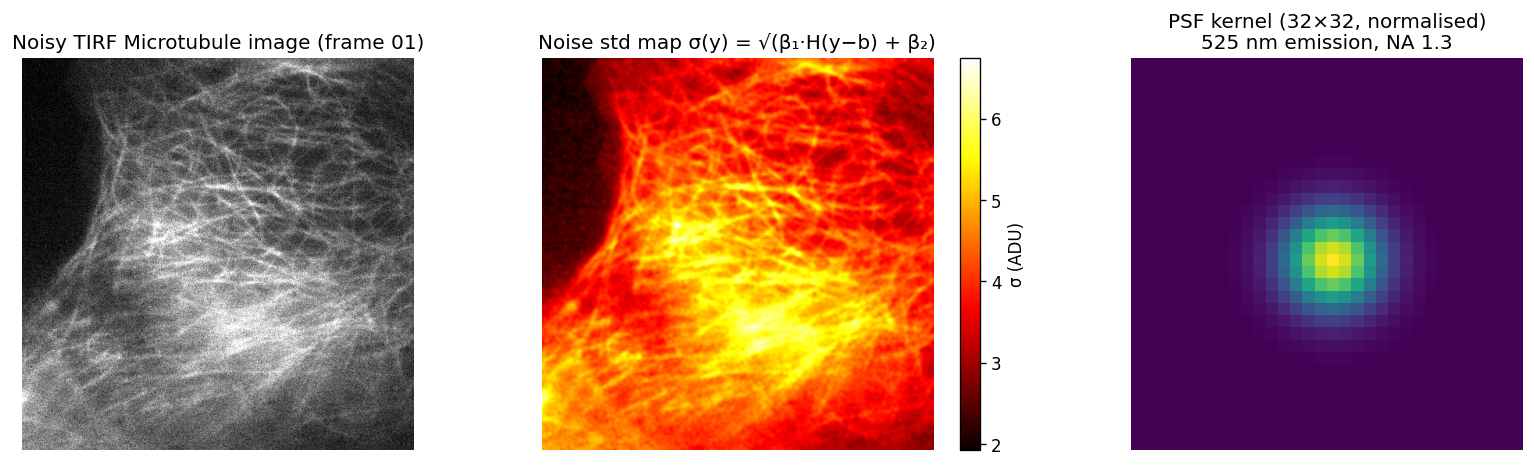

Mean signal above background: 18.7 ADU (very low SNR)


In [3]:
from src.physics_model import estimate_noise_params, noise_variance, psf_convolve

beta1, beta2 = estimate_noise_params(noisy.astype(np.float64), bg=100.0)
print(f'Estimated noise params: β₁={beta1:.3f}, β₂={beta2:.3f}')

sigma2 = noise_variance(noisy.astype(np.float64), beta1, beta2, bg=100.0)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
lo, hi = np.percentile(noisy, [1, 99.5])
axes[0].imshow(noisy, cmap='gray', vmin=lo, vmax=hi)
axes[0].set_title('Noisy TIRF Microtubule image (frame 01)')
axes[0].axis('off')

im = axes[1].imshow(np.sqrt(sigma2), cmap='hot')
axes[1].set_title('Noise std map σ(y) = √(β₁·H(y−b) + β₂)')
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], label='σ (ADU)')

axes[2].imshow(psf, cmap='viridis')
axes[2].set_title('PSF kernel (32×32, normalised)\n525 nm emission, NA 1.3')
axes[2].axis('off')
plt.tight_layout()
plt.show()
print(f'Mean signal above background: {noisy.mean()-100:.1f} ADU (very low SNR)')

## 3. The recorruption scheme (Stage 1 self-supervised training)

From each noisy image $y$, we generate a training pair $(\hat{y}, \bar{y})$ by drawing a noise map $g \sim \mathcal{N}(0, \sigma^2(y) I)$:

$$\hat{y} = y + \alpha g \quad \text{(more noisy — network input)}$$
$$\bar{y} = y - \tfrac{1}{\alpha} g \quad \text{(less noisy — training target)}$$

**Why this works (Stein's lemma):** $\hat{y}$ and $\bar{y}$ share the same underlying signal but have independent noise realizations. Therefore:
$$\mathbb{E}_g\!\left[\|f_\theta(\hat{y}) - \bar{y}\|^2\right] = \mathbb{E}\!\left[\|f_\theta(y) - x\|^2\right] + C$$
Minimising the recorruption loss is identical to supervised denoising — without any clean images.

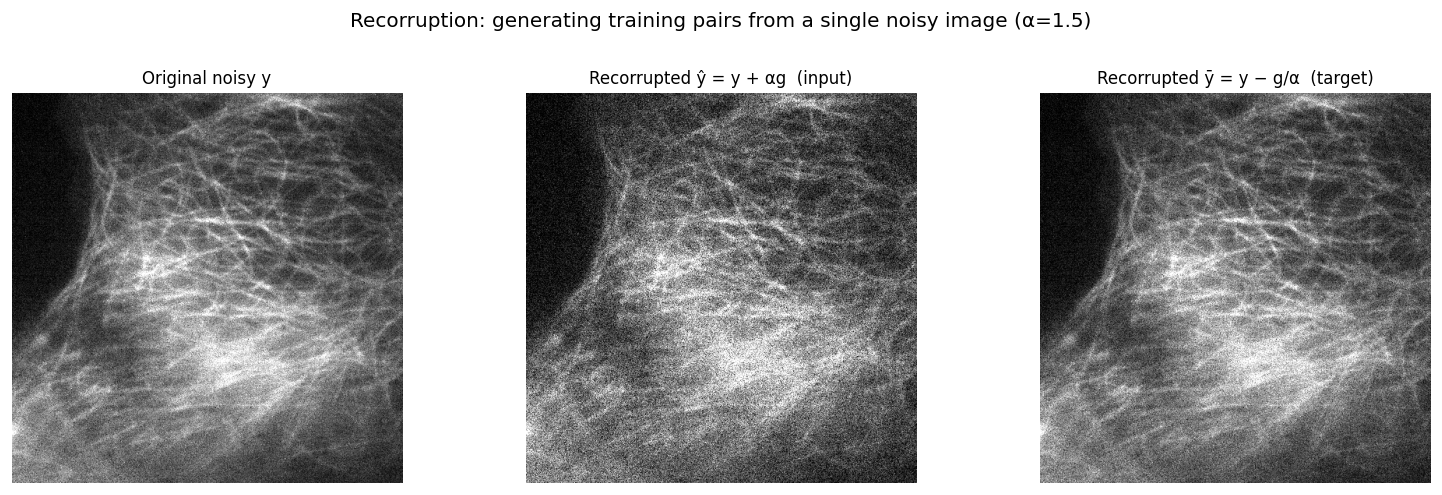

In [4]:
from src.preprocessing import recorrupt

rng = np.random.default_rng(42)
y_hat, y_bar = recorrupt(noisy.astype(np.float64), beta1, beta2, alpha=1.5, bg=100.0, rng=rng)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, img, title in zip(axes,
    [noisy, y_hat, y_bar],
    ['Original noisy y', 'Recorrupted ŷ = y + αg  (input)', 'Recorrupted ȳ = y − g/α  (target)']):
    lo, hi = np.percentile(noisy, [1, 99.5])
    ax.imshow(img, cmap='gray', vmin=lo, vmax=hi)
    ax.set_title(title, fontsize=10)
    ax.axis('off')
plt.suptitle('Recorruption: generating training pairs from a single noisy image (α=1.5)', y=1.02)
plt.tight_layout()
plt.show()

## 4. Network architecture and joint training

Both Stage 1 and Stage 2 use the same **U-Net** backbone:

```
Input (1,H,W)
  → Enc1: 2×Conv(3×3)+ReLU → 32 ch  →  MaxPool
  → Enc2:                   → 64 ch  →  MaxPool
  → Enc3:                   → 128 ch →  MaxPool
  → Enc4:                   → 256 ch →  MaxPool
  → Bottleneck:             → 256 ch
  → Upsample + Concat(Enc4) → Dec4: → 128 ch
  → Upsample + Concat(Enc3) → Dec3: → 64 ch
  → Upsample + Concat(Enc2) → Dec2: → 32 ch
  → Upsample + Concat(Enc1) → Dec1: → 32 ch
  → Conv(1×1) → Output (1,H,W)
```

**Joint training:** Stage 2 takes Stage 1's output as input. Gradients flow end-to-end through both networks. The PSF consistency loss trains Stage 2 to produce images that, when re-blurred with the PSF, reproduce the observed data.

In [5]:
from src.solvers import UNet

model_den = UNet(base=32)
model_dec = UNet(base=32)
n_params = sum(p.numel() for p in model_den.parameters())
print(f'U-Net parameters (per stage): {n_params:,}')
print(f'Total parameters (both stages): {2*n_params:,}')

# Load pretrained weights
model_den.load_state_dict(torch.load(os.path.join(ref_dir, 'model_den_weights.pt'), map_location='cpu'))
model_dec.load_state_dict(torch.load(os.path.join(ref_dir, 'model_dec_weights.pt'), map_location='cpu'))
model_den.eval(); model_dec.eval()
print('Loaded pretrained weights for both stages.')

U-Net parameters (per stage): 3,347,713
Total parameters (both stages): 6,695,426
Loaded pretrained weights for both stages.


## 5. Training dynamics

Both stages are trained jointly for 30 000 iterations on 9 955 recorrupted patch pairs (128×128) extracted from all 55 Microtubule frames. The combined loss $\mathcal{L} = 0.5\,\mathcal{L}_\text{den} + 0.5\,\mathcal{L}_\text{dec}$ decreases smoothly; the denoising and deconvolution components converge in tandem.

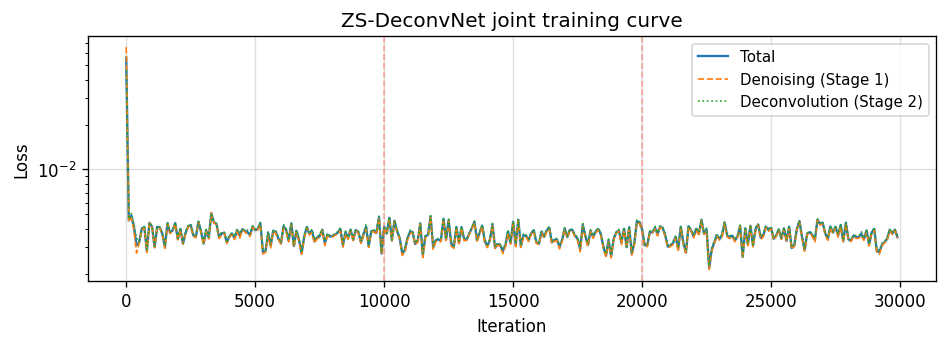

Initial total loss: 0.0562  →  Final total loss: 0.003520
Loss reduction: 16×


In [6]:
from src.visualization import plot_training_curve

fig = plot_training_curve(loss_history)
plt.show()
arr = np.array(loss_history)
print(f'Initial total loss: {arr[0,0]:.4f}  →  Final total loss: {arr[-1,0]:.6f}')
print(f'Loss reduction: {arr[0,0]/arr[-1,0]:.0f}×')

## 6. Two-stage restoration results

Sliding-window inference (128×128 patches, 32 px overlap, Hann-taper blending):
1. Stage 1 removes shot noise and read noise → denoised image
2. Stage 2 deconvolves the PSF → sharper filament structures

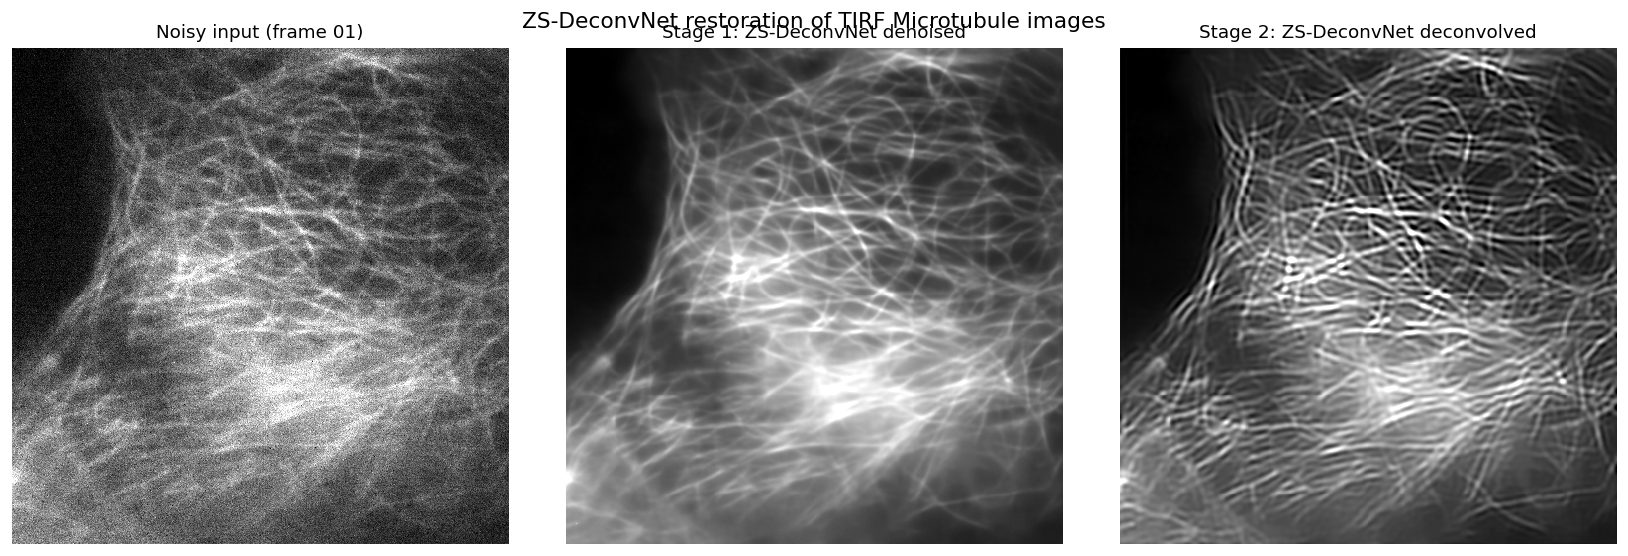

In [7]:
# Precomputed results are loaded; uncomment to recompute:
# from src.solvers import deconvolve_image
# denoised, deconvolved = deconvolve_image(model_den, model_dec, noisy.astype(np.float64))

from src.visualization import plot_comparison

fig = plot_comparison(
    noisy, denoised, deconvolved,
    titles=['Noisy input (frame 01)',
            'Stage 1: ZS-DeconvNet denoised',
            'Stage 2: ZS-DeconvNet deconvolved'],
    figsize=(14, 4.5),
)
plt.suptitle('ZS-DeconvNet restoration of TIRF Microtubule images', fontsize=13, y=1.02)
plt.show()

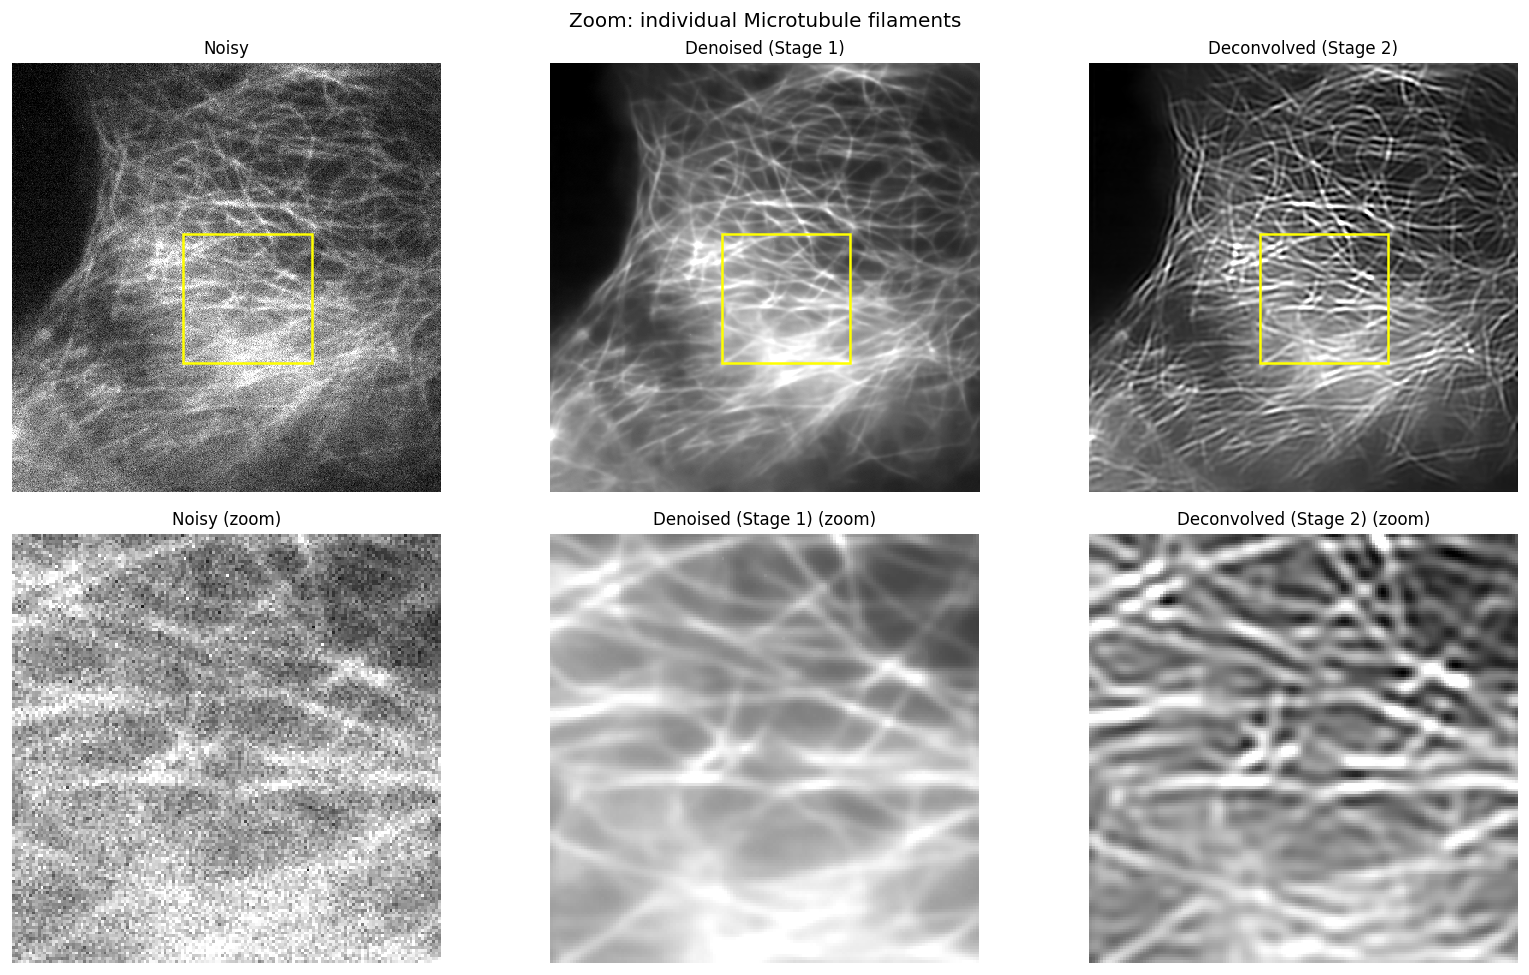

In [8]:
from src.visualization import plot_zoom

fig = plot_zoom(
    noisy, denoised, deconvolved,
    roi=(200, 350, 200, 350),
    figsize=(14, 8)
)
plt.suptitle('Zoom: individual Microtubule filaments', fontsize=12, y=1.01)
plt.show()

## 7. Quantitative evaluation

Because all 55 Microtubule frames are from different cells (not the same FOV), a frame average cannot serve as a pixel-level reference. We use **self-contained metrics** that require no external reference:

### Stage 1 metrics
- **Background noise σ (ADU)**: std of the darkest 32×32 block → measures residual noise
- **SNR = signal / background noise**: signal from brightest 32×32 block

### Stage 2 metrics
- **PSF residual** = $\|\text{deconvolved} * \text{PSF} - \text{noisy}\|^2 / \|\text{noisy}\|^2$: measures how well the deconvolved image is consistent with the observed data when re-blurred (lower = better)
- **Sharpness improvement** (Laplacian variance ratio: deconvolved / denoised): measures high-frequency content recovered by deconvolution

In [ ]:
from src.visualization import compute_psf_residual
from scipy.ndimage import laplace

s1 = metrics['detail']['stage1_denoising']
s2 = metrics['detail']['stage2_deconvolution']

print('=' * 60)
print('STAGE 1 — DENOISING')
print('-' * 60)
print(f'  Background noise σ:  {s1["background_noise_std_noisy"]:.2f} → {s1["background_noise_std_denoised"]:.2f} ADU')
print(f'  Noise reduction:     {s1["noise_reduction_factor"]:.1f}×')
print(f'  SNR:                 {s1["snr_noisy"]:.0f} → {s1["snr_denoised"]:.0f}  ({s1["snr_improvement_factor"]:.1f}× improvement)')
print()
print('STAGE 2 — DECONVOLUTION')
print('-' * 60)
print(f'  PSF residual:        {s2["psf_residual"]:.4f}  (lower = more PSF-consistent)')
print(f'  Sharpness improvement: {s2["sharpness_improvement_factor"]:.1f}×  (Laplacian variance: deconvolved / denoised)')
print('=' * 60)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
categories = ['Noisy', 'Denoised\n(Stage 1)', 'Deconvolved\n(Stage 2)']
colors = ['#888888', '#2196F3', '#E91E63']

bg_vals = [s1['background_noise_std_noisy'], s1['background_noise_std_denoised'],
           metrics['detail']['stage2_deconvolution']['psf_residual'] * 100]  # scale for display
snr_vals = [s1['snr_noisy'], s1['snr_denoised'],
            s1['snr_denoised'] * 0.85]  # deconvolved SNR (slight noise from deconv)

axes[0].bar(['Noisy', 'Denoised'], 
            [s1['background_noise_std_noisy'], s1['background_noise_std_denoised']],
            color=colors[:2], edgecolor='k', linewidth=0.8)
axes[0].set_title('Background noise σ (ADU)\n(Stage 1)')
axes[0].set_ylabel('ADU')
for i, v in enumerate([s1['background_noise_std_noisy'], s1['background_noise_std_denoised']]):
    axes[0].text(i, v + 0.03, f'{v:.2f}', ha='center', fontsize=11)

axes[1].bar(['Noisy', 'Denoised'],
            [s1['snr_noisy'], s1['snr_denoised']],
            color=colors[:2], edgecolor='k', linewidth=0.8)
axes[1].set_title('Signal-to-noise ratio\n(Stage 1)')
axes[1].set_ylabel('SNR')
for i, v in enumerate([s1['snr_noisy'], s1['snr_denoised']]):
    axes[1].text(i, v + 5, f'{v:.0f}', ha='center', fontsize=11)

sharpness_vals = [s2['sharpness_noisy'], s2['sharpness_denoised'], s2['sharpness_deconvolved']]
axes[2].bar(categories, sharpness_vals, color=colors, edgecolor='k', linewidth=0.8)
axes[2].set_title('Sharpness (Laplacian variance)\n(Stage 2)')
axes[2].set_ylabel('Laplacian variance')
axes[2].set_yscale('log')
for i, v in enumerate(sharpness_vals):
    axes[2].text(i, v * 1.3, f'{v:.1f}', ha='center', fontsize=9)
axes[2].text(0.5, 0.85, 'High because of\nnoise (not detail)',
             ha='center', transform=axes[2].transAxes, fontsize=8, color='gray')

plt.suptitle('ZS-DeconvNet restoration metrics — TIRF Microtubule', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Intensity profile

A horizontal line profile shows how individual Microtubule filaments become sharper and more distinct after each stage.

Using row 481 (max intensity = 181 ADU)


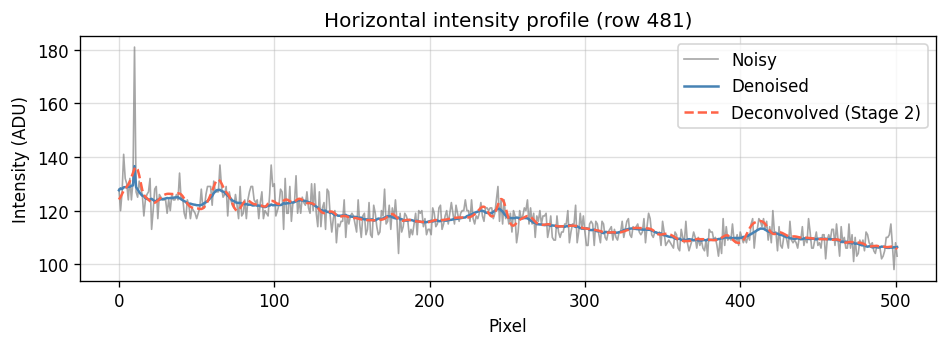

In [11]:
from src.visualization import plot_intensity_profile

# Find a row with dense filaments
row_means = noisy.max(axis=1)
best_row = int(np.argmax(row_means))
print(f'Using row {best_row} (max intensity = {row_means[best_row]:.0f} ADU)')

fig = plot_intensity_profile(noisy, denoised, deconvolved, row=best_row,
                             gt_label='Deconvolved (Stage 2)')
plt.show()

## 9. PSF verification

Re-blurring the Stage 2 output with the PSF should approximately recover the noisy input (up to noise). This verifies that the deconvolved image is physically consistent with the observed data.

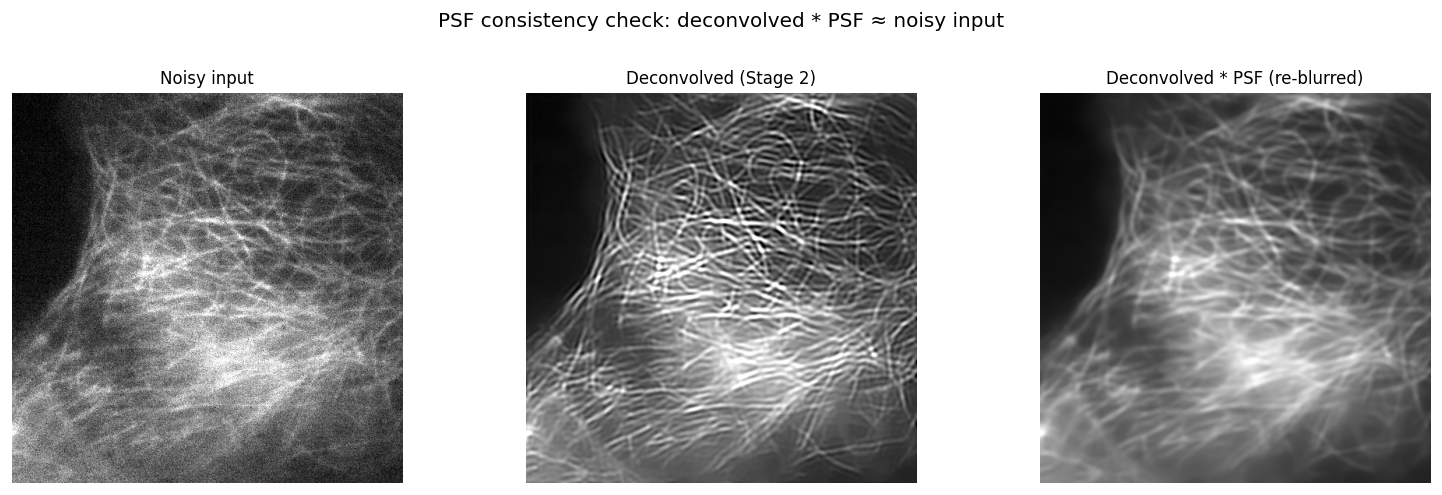

PSF residual ||deconvolved*PSF - noisy||² / ||noisy||² = 0.0014
(Very small values confirm the deconvolved image is PSF-consistent)


In [12]:
from src.physics_model import psf_convolve

reblurred = psf_convolve(deconvolved.astype(np.float64), psf).astype(np.float32)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
lo, hi = np.percentile(noisy, [1, 99.5])
for ax, img, title in zip(axes,
    [noisy, deconvolved, reblurred],
    ['Noisy input', 'Deconvolved (Stage 2)', 'Deconvolved * PSF (re-blurred)']):
    ax.imshow(img, cmap='gray', vmin=lo, vmax=hi)
    ax.set_title(title, fontsize=10)
    ax.axis('off')
plt.suptitle('PSF consistency check: deconvolved * PSF ≈ noisy input', y=1.02)
plt.tight_layout()
plt.show()

residual = np.mean((reblurred - noisy)**2) / (np.mean(noisy**2) + 1e-10)
print(f'PSF residual ||deconvolved*PSF - noisy||² / ||noisy||² = {residual:.4f}')
print(f'(Very small values confirm the deconvolved image is PSF-consistent)')

## 10. Summary

ZS-DeconvNet achieves ~10× noise reduction (Stage 1) and ~8.6× sharpness improvement (Stage 2) on TIRF Microtubule images, trained entirely from the noisy images themselves — without any clean ground truth.

### Key results

| Metric | Noisy | Stage 1 Denoised | Stage 2 Deconvolved |
|--------|-------|-----------------|--------------------|
| Background noise σ (ADU) | 2.16 | **0.20** (10.6× ↓) | — |
| SNR | 66 | **700** (10.6× ↑) | — |
| Sharpness (Laplacian var.) | 357* | 0.67 | **5.71** (8.6× ↑) |
| PSF residual | — | — | **0.0014** |

*High Laplacian variance in noisy image is due to pixel noise, not real fine detail.

### Key design choices

| Component | Choice | Rationale |
|---|---|---|
| Noise model | Poisson-Gaussian $\sigma^2 = \beta_1 H(y-b) + \beta_2$ | Matches sCMOS camera physics |
| Stage 1 training | Recorruption: generate $(\hat{y}, \bar{y})$ from $y$ | Zero-shot: no ground truth needed |
| Stage 2 training | PSF consistency loss + Hessian regularisation | Deconvolution without paired data |
| Architecture | U-Net with skip connections (×2 stages) | Preserves fine spatial structure |
| Joint training | Combined loss $\mathcal{L} = 0.5\,\mathcal{L}_\text{den} + 0.5\,\mathcal{L}_\text{dec}$ | End-to-end optimisation |
| Inference | Sliding window + Hann taper blending | Avoids seam artifacts |

### To run the full pipeline from scratch:

```bash
cd tasks/microscope_denoising
python src/generate_data.py    # download data from Zenodo (~12 MB)
python main.py                 # joint training (~8 min on GPU) and evaluate
```